# 04 · 话题 × 情感 × 平台 交叉分析

聚类（03 TF-IDF / 03b 句向量）最多只能切出 **K=2** 的粗划分，给不出报告需要的
甜度 / 功效 / 价格 / 国际化 四个维度。本 notebook 改用**规则式话题桶**做交叉分析。

**话题定义**来自 `src/text_utils.TOPICS`（与 02 同一定义源，已验证能精确复现 02 存档的
`topics` 列）。一条评论可命中多个话题，所以各话题占比之和 > 100%。

### 样本量规则（本次强制执行）

- **每个交叉格子都标注 n**；
- **n < 20 的格子标注「样本不足」，不下结论**，图上用灰色斜纹标出；
- 重点话题：**甜度口味 / 功效上火 / 价格 / 国际化**。

### 先说结论：四个重点话题里有两个做不了

| 话题 | 主结果 n (260) | 全年份相关集 n (479) | 可否下结论 |
|---|---|---|---|
| 功效上火 | 47 | 80 | ✓ |
| 甜度口味 | 39 | 76 | ✓ |
| 国际化 | **14** | **16** | ✗ 样本不足 |
| 价格 | **5** | **9** | ✗ 样本不足 |

价格和国际化即使把样本从 2023+ 扩到全部年份仍不达标——**这两个维度这批数据支撑不了**，
下面会照样把数字列出来，但一律标注为不可下结论。

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')

PROJ = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJ / 'src'))
import text_utils as T

PROC = PROJ / 'data' / 'processed'
FIG  = PROJ / 'outputs' / 'figures'

font = T.get_cjk_font(verbose=True)          # 跨平台中文字体，含回退
plt.rcParams['figure.dpi'] = 110

MIN_N   = T.MIN_CELL_N          # 20
FOCUS   = T.FOCUS_TOPICS
ORDER   = ['正面', '负面', '中性']
COLORS  = {'正面': '#66c2a5', '负面': '#fc8d62', '中性': '#8da0cb'}

df = pd.read_csv(PROC / 'comments_sentiment.csv', encoding='utf-8-sig',
                 parse_dates=['created_at'])
df['topics'] = df['topics'].fillna('')

# 一致性校验：共享定义必须能复现 02 存档的 topics 列
_rederived = df['content_clean'].map(lambda s: '|'.join(T.topic_hits(s)))
assert (_rederived == df['topics']).all(), '话题定义与 02 存档不一致'
print('✓ 话题定义与 02 存档一致')

PRI = df[df['is_primary']].copy()          # 主结果：2023+ 相关集
REL = df[df['on_topic']].copy()            # 扩展：全年份相关集

for name in T.TOPICS:
    PRI[name] = PRI['topics'].str.contains(name)
    REL[name] = REL['topics'].str.contains(name)

print()
print('主结果 (2023+ 相关集) n =', len(PRI))
print('扩展   (全年份相关集) n =', len(REL))
print()
print('话题桶定义 :')
for k, v in T.TOPICS.items():
    star = '★' if k in FOCUS else ' '
    print(f'  {star} {k:6s} : {"、".join(v)}')

中文字体: SimHei
✓ 话题定义与 02 存档一致

主结果 (2023+ 相关集) n = 260
扩展   (全年份相关集) n = 479

话题桶定义 :
  ★ 甜度口味   : 甜、太甜、糖水、含糖、无糖、低糖、齁、腻、口味、好喝、难喝、味道
  ★ 功效上火   : 上火、降火、清热、功效、去火、中药、草本、凉性、药味、养生
  ★ 价格     : 贵、便宜、价格、性价比、智商税、划算、多少钱、涨价
    包装设计   : 包装、设计、罐、瓶、颜值、好看、红罐、外观
    竞品商标   : 加多宝、和其正、商标、官司、分家、侵权、纠纷
  ★ 国际化    : 国际罐、WALOVI、海外、出海、国外、外国、全球、英文
    怀旧广告   : 广告、怕上火、小时候、童年、记忆、以前、代言、春晚


## 1. 样本量审计

先把每个话题的 n 摊开，决定哪些能往下分析。

In [2]:
def audit(frame, label):
    rows = []
    for name in T.TOPICS:
        n = int(frame[name].sum())
        rows.append({'话题': name,
                     '重点': '★' if name in FOCUS else '',
                     'n': n,
                     '占比%': round(n / len(frame) * 100, 1),
                     '状态': '可分析' if n >= MIN_N else f'样本不足(<{MIN_N})'})
    t = pd.DataFrame(rows).sort_values('n', ascending=False)
    print(f'=== {label} (总 n = {len(frame)}) ===')
    print(t.to_string(index=False))
    print()
    return t


aud_pri = audit(PRI, '主结果 · 2023+ 相关集')
aud_rel = audit(REL, '扩展 · 全年份相关集')

USABLE = [r['话题'] for _, r in aud_pri.iterrows() if r['n'] >= MIN_N]
BLOCKED_FOCUS = [t for t in FOCUS if t not in USABLE]
print('可分析话题        :', USABLE)
print('重点话题中不可用的 :', BLOCKED_FOCUS, '-> 这些只列数字，不下结论')

=== 主结果 · 2023+ 相关集 (总 n = 260) ===
  话题 重点   n  占比%        状态
竞品商标    106 40.8       可分析
功效上火  ★  47 18.1       可分析
包装设计     41 15.8       可分析
甜度口味  ★  39 15.0       可分析
怀旧广告     30 11.5       可分析
 国际化  ★  14  5.4 样本不足(<20)
  价格  ★   5  1.9 样本不足(<20)

=== 扩展 · 全年份相关集 (总 n = 479) ===
  话题 重点   n  占比%        状态
竞品商标    247 51.6       可分析
包装设计     87 18.2       可分析
功效上火  ★  80 16.7       可分析
甜度口味  ★  76 15.9       可分析
怀旧广告     68 14.2       可分析
 国际化  ★  16  3.3 样本不足(<20)
  价格  ★   9  1.9 样本不足(<20)

可分析话题        : ['竞品商标', '功效上火', '包装设计', '甜度口味', '怀旧广告']
重点话题中不可用的 : ['价格', '国际化'] -> 这些只列数字，不下结论


## 2. 话题 × 情感（主结果）

每格标 n；n < 20 的行整行标注样本不足。

In [3]:
rows = []
for name in T.TOPICS:
    sub = PRI[PRI[name]]
    n = len(sub)
    vc = sub['sentiment'].value_counts().reindex(ORDER).fillna(0).astype(int)
    rows.append({'话题': name, '重点': '★' if name in FOCUS else '',
                 'n': n,
                 '正面n': vc['正面'], '负面n': vc['负面'], '中性n': vc['中性'],
                 '正面%': round(vc['正面'] / n * 100, 1) if n else np.nan,
                 '负面%': round(vc['负面'] / n * 100, 1) if n else np.nan,
                 '中性%': round(vc['中性'] / n * 100, 1) if n else np.nan,
                 '净情感(正-负)': round((vc['正面'] - vc['负面']) / n * 100, 1) if n else np.nan,
                 '结论': '可下结论' if n >= MIN_N else '样本不足'})
TS = pd.DataFrame(rows).sort_values('n', ascending=False)
print('=== 话题 × 情感（主结果 2023+ 相关集，n=%d）===' % len(PRI))
print(TS.to_string(index=False))
print()
print('注：各话题占比之和 > 100%%，因为一条评论可命中多个话题。')
print('全样本基线情感 : ' +
      '  '.join(f'{k} {v:.1f}%' for k, v in
                (PRI['sentiment'].value_counts(normalize=True) * 100).reindex(ORDER).items()))

=== 话题 × 情感（主结果 2023+ 相关集，n=260）===
  话题 重点   n  正面n  负面n  中性n  正面%  负面%  中性%  净情感(正-负)   结论
竞品商标    106   27   58   21 25.5 54.7 19.8     -29.2 可下结论
功效上火  ★  47   16   20   11 34.0 42.6 23.4      -8.5 可下结论
包装设计     41   10   22    9 24.4 53.7 22.0     -29.3 可下结论
甜度口味  ★  39   16   15    8 41.0 38.5 20.5       2.6 可下结论
怀旧广告     30   12    7   11 40.0 23.3 36.7      16.7 可下结论
 国际化  ★  14   11    0    3 78.6  0.0 21.4      78.6 样本不足
  价格  ★   5    0    3    2  0.0 60.0 40.0     -60.0 样本不足

注：各话题占比之和 > 100%%，因为一条评论可命中多个话题。
全样本基线情感 : 正面 35.0%  负面 45.4%  中性 19.6%


### 图：话题 × 情感（n 全部标注，样本不足打斜纹）

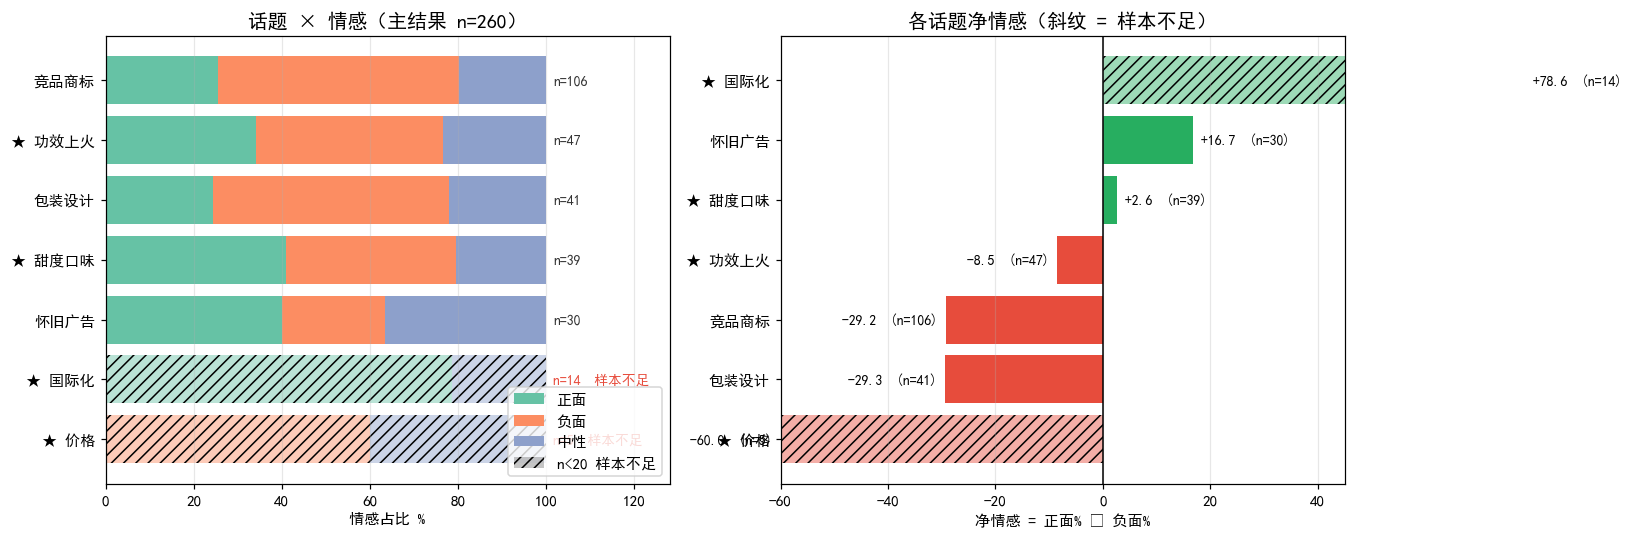

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

d = TS.sort_values('n', ascending=True)
y = np.arange(len(d))
left = np.zeros(len(d))
for k in ORDER:
    vals = (d[k + 'n'] / d['n'] * 100).values
    bars = ax[0].barh(y, vals, left=left, color=COLORS[k], label=k)
    for i, b in enumerate(bars):
        if d['n'].values[i] < MIN_N:
            b.set_hatch('///'); b.set_alpha(.45)
    left += vals
for i, (_, r) in enumerate(d.iterrows()):
    tag = f"n={r['n']}" + ('  样本不足' if r['n'] < MIN_N else '')
    ax[0].text(101.5, i, tag, va='center', fontproperties=font, fontsize=9,
               color='#E74C3C' if r['n'] < MIN_N else '#333')
ax[0].set_yticks(y)
ax[0].set_yticklabels([('★ ' if t in FOCUS else '') + t for t in d['话题']],
                      fontproperties=font)
ax[0].set_xlim(0, 128)
ax[0].set_xlabel('情感占比 %', fontproperties=font)
ax[0].set_title('话题 × 情感（主结果 n=%d）' % len(PRI), fontproperties=font, fontsize=13)
h = [Patch(facecolor=COLORS[k], label=k) for k in ORDER] + \
    [Patch(facecolor='grey', hatch='///', alpha=.45, label=f'n<{MIN_N} 样本不足')]
ax[0].legend(handles=h, prop=font, fontsize=8, loc='lower right')
ax[0].grid(alpha=.3, axis='x')

d2 = TS.sort_values('净情感(正-负)')
cols = ['#E74C3C' if v < 0 else '#27AE60' for v in d2['净情感(正-负)']]
bars = ax[1].barh(np.arange(len(d2)), d2['净情感(正-负)'], color=cols)
for i, b in enumerate(bars):
    if d2['n'].values[i] < MIN_N:
        b.set_hatch('///'); b.set_alpha(.45)
    v = d2['净情感(正-负)'].values[i]
    ax[1].text(v + (1.5 if v >= 0 else -1.5), i,
               f"{v:+.1f}  (n={d2['n'].values[i]})",
               va='center', ha='left' if v >= 0 else 'right',
               fontproperties=font, fontsize=9)
ax[1].axvline(0, color='black', lw=1)
ax[1].set_yticks(np.arange(len(d2)))
ax[1].set_yticklabels([('★ ' if t in FOCUS else '') + t for t in d2['话题']],
                      fontproperties=font)
ax[1].set_xlabel('净情感 = 正面% − 负面%', fontproperties=font)
ax[1].set_title('各话题净情感（斜纹 = 样本不足）', fontproperties=font, fontsize=13)
ax[1].set_xlim(-60, 45)
ax[1].grid(alpha=.3, axis='x')

plt.tight_layout()
plt.savefig(FIG / '04_topic_sentiment.png', bbox_inches='tight')
plt.show()

## 3. 话题 × 平台（主结果）

热力图每格标 n，n < 20 打斜纹。

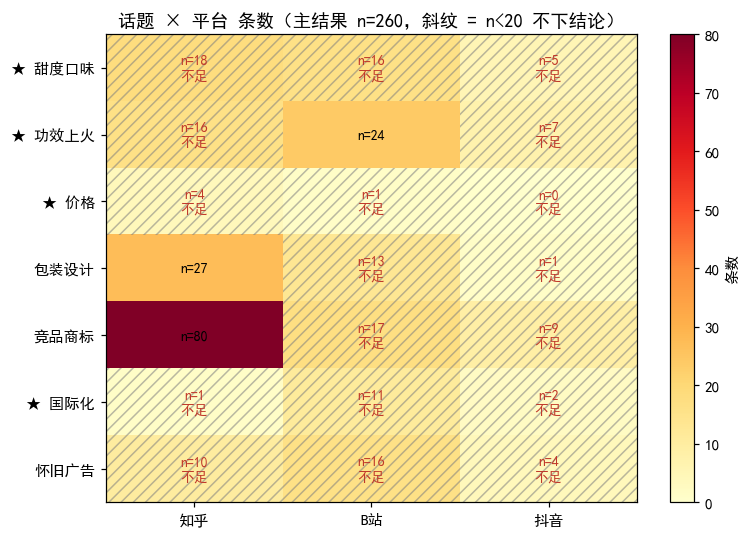

=== 话题 × 平台 条数（主结果）===
      知乎  B站  抖音   合计
甜度口味  18  16   5   39
功效上火  16  24   7   47
价格     4   1   0    5
包装设计  27  13   1   41
竞品商标  80  17   9  106
国际化    1  11   2   14
怀旧广告  10  16   4   30

共 21 个格子，其中 18 个 (n<20) 不可下结论 = 86%
-> 话题按平台拆分后几乎全部低于门槛，平台级话题结论不可做。


In [5]:
ct = pd.DataFrame({p: [int(PRI[(PRI[t]) & (PRI['platform'] == p)].shape[0])
                       for t in T.TOPICS]
                   for p in PRI['platform'].value_counts().index},
                  index=list(T.TOPICS))
ct['合计'] = ct.sum(axis=1)

fig, ax = plt.subplots(figsize=(7.2, 5))
data = ct.drop(columns='合计')
im = ax.imshow(data.values, cmap='YlOrRd', aspect='auto')
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        n = data.values[i, j]
        insuf = n < MIN_N
        ax.text(j, i, f'n={n}' + ('\n不足' if insuf else ''), ha='center', va='center',
                fontproperties=font, fontsize=9,
                color='#C0392B' if insuf else 'black')
        if insuf:
            ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=False,
                                       hatch='///', edgecolor='grey', lw=0, alpha=.55))
ax.set_xticks(range(data.shape[1]))
ax.set_xticklabels(data.columns, fontproperties=font)
ax.set_yticks(range(data.shape[0]))
ax.set_yticklabels([('★ ' if t in FOCUS else '') + t for t in data.index],
                   fontproperties=font)
ax.set_title(f'话题 × 平台 条数（主结果 n={len(PRI)}，斜纹 = n<{MIN_N} 不下结论）',
             fontproperties=font, fontsize=12)
plt.colorbar(im, label='条数')
plt.tight_layout()
plt.savefig(FIG / '04_topic_platform.png', bbox_inches='tight')
plt.show()

print('=== 话题 × 平台 条数（主结果）===')
print(ct.to_string())
print()
tot = data.size
insuf = int((data.values < MIN_N).sum())
print(f'共 {tot} 个格子，其中 {insuf} 个 (n<{MIN_N}) 不可下结论 '
      f'= {insuf/tot*100:.0f}%')
print('-> 话题按平台拆分后几乎全部低于门槛，平台级话题结论不可做。')

## 4. 四个重点话题：情感分布 + 样本量

对每个重点话题单独出图；`价格` 与 `国际化` 会被标为样本不足。
同时给出「扩展到全年份」是否能救回来的对照。

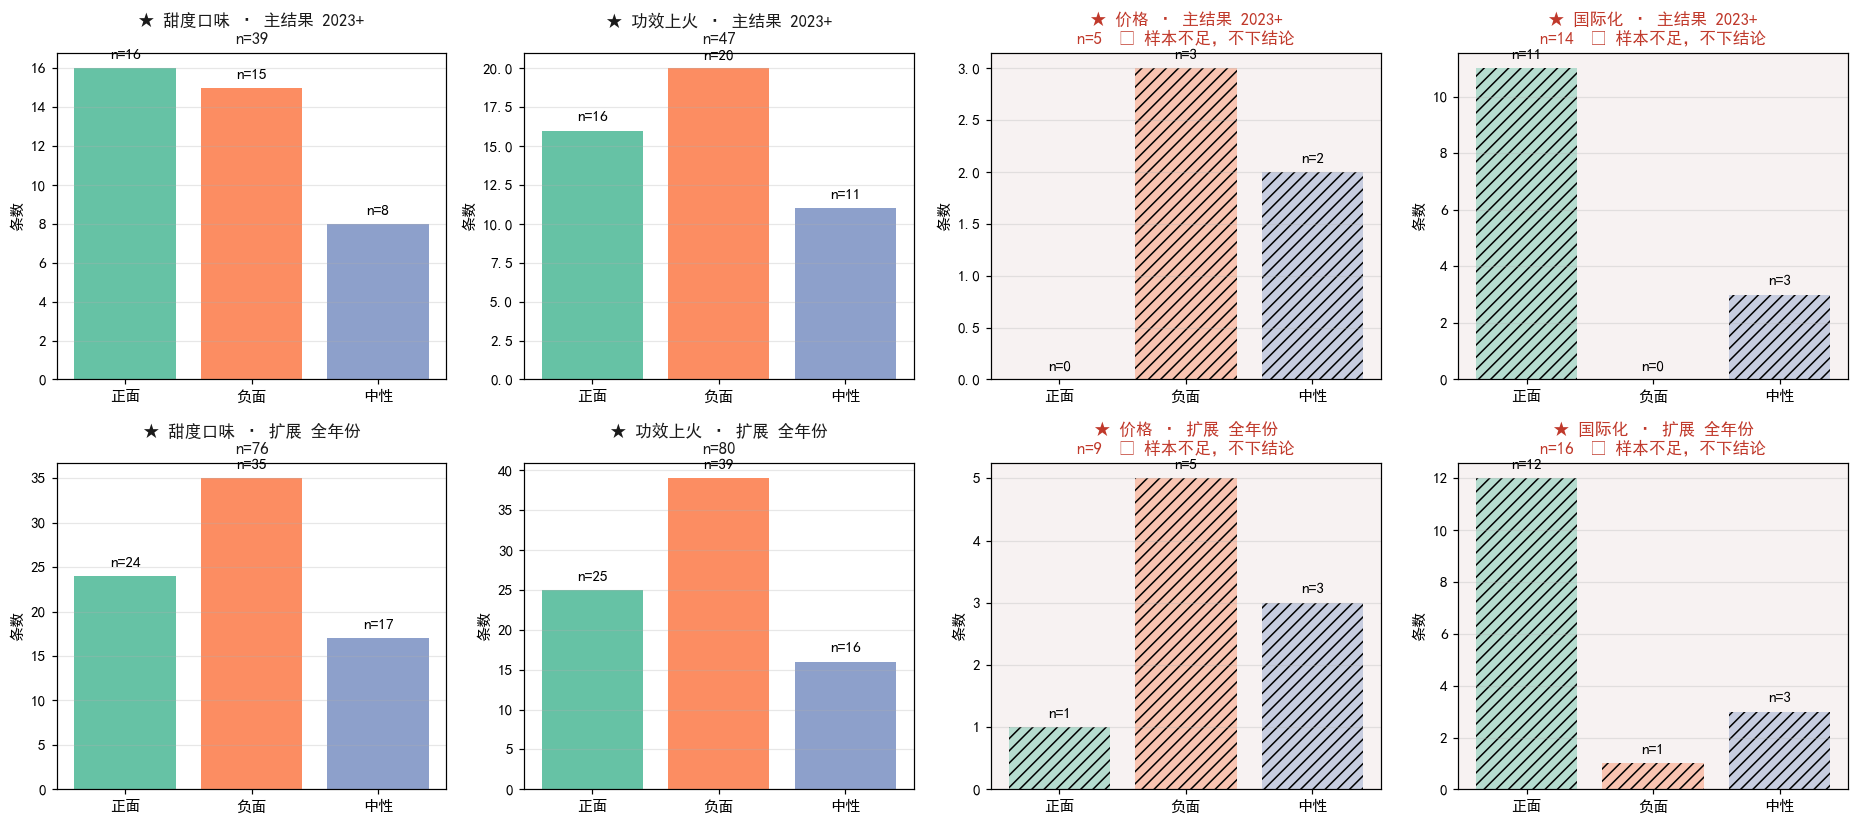

=== 四个重点话题汇总 ===
  话题  主结果n  扩展n  正面%  负面%  中性%   净情感   状态 扩展后仍不足
甜度口味    39   76 41.0 38.5 20.5   2.6 可下结论      否
功效上火    47   80 34.0 42.6 23.4  -8.5 可下结论      否
  价格     5    9  0.0 60.0 40.0 -60.0 样本不足      是
 国际化    14   16 78.6  0.0 21.4  78.6 样本不足      是


In [6]:
fig, axes = plt.subplots(2, 4, figsize=(17, 7.6))
summary = []
for j, t in enumerate(FOCUS):
    for row, (frame, lab) in enumerate([(PRI, '主结果 2023+'), (REL, '扩展 全年份')]):
        a = axes[row, j]
        sub = frame[frame[t]]
        n = len(sub)
        vc = sub['sentiment'].value_counts().reindex(ORDER).fillna(0).astype(int)
        insuf = n < MIN_N
        bars = a.bar(ORDER, vc.values, color=[COLORS[k] for k in ORDER])
        for b in bars:
            if insuf:
                b.set_hatch('///'); b.set_alpha(.45)
            a.text(b.get_x() + b.get_width()/2, b.get_height() + max(vc.max(), 1) * .03,
                   f'n={int(b.get_height())}', ha='center',
                   fontproperties=font, fontsize=10)
        a.set_title(f'{"★ " if True else ""}{t} · {lab}\nn={n}' +
                    ('  ⚠ 样本不足，不下结论' if insuf else ''),
                    fontproperties=font, fontsize=11,
                    color='#C0392B' if insuf else '#1a1a1a')
        a.set_xticks(range(len(ORDER)))
        a.set_xticklabels(ORDER, fontproperties=font)
        a.set_ylabel('条数', fontproperties=font)
        a.grid(alpha=.3, axis='y')
        if insuf:
            a.set_facecolor('#f7f2f2')
        if row == 0:
            summary.append({'话题': t, '主结果n': n,
                            '正面%': round(vc['正面']/n*100, 1) if n else np.nan,
                            '负面%': round(vc['负面']/n*100, 1) if n else np.nan,
                            '中性%': round(vc['中性']/n*100, 1) if n else np.nan,
                            '净情感': round((vc['正面']-vc['负面'])/n*100, 1) if n else np.nan,
                            '状态': '样本不足' if insuf else '可下结论'})
        else:
            summary[j]['扩展n'] = n
            summary[j]['扩展后仍不足'] = '是' if n < MIN_N else '否'

plt.tight_layout()
plt.savefig(FIG / '04_focus_topics.png', bbox_inches='tight')
plt.show()

SUM = pd.DataFrame(summary)[['话题', '主结果n', '扩展n', '正面%', '负面%', '中性%',
                             '净情感', '状态', '扩展后仍不足']]
print('=== 四个重点话题汇总 ===')
print(SUM.to_string(index=False))

## 5. 可分析话题的代表评论

只对 n ≥ 20 的重点话题抽样，样本不足的不抽（避免用个例暗示结论）。

片段仅用于方法说明，已截断至 40 字并去除所有标识信息，不指向具体用户。

In [7]:
for t in FOCUS:
    sub = PRI[PRI[t]]
    n = len(sub)
    print('=' * 76)
    if n < MIN_N:
        print(f'【{t}】n={n} < {MIN_N} —— 样本不足，不抽样、不下结论')
        print(f'  （全部 {n} 条仅作存档，见 data/processed/topic_focus_rows.csv）')
        continue
    print(f'【{t}】n={n}  '
          f"正面 {(sub['sentiment']=='正面').sum()} / "
          f"负面 {(sub['sentiment']=='负面').sum()} / "
          f"中性 {(sub['sentiment']=='中性').sum()}")
    for lab in ['负面', '正面']:
        s2 = sub[sub['sentiment'] == lab].nlargest(3, 'n_tokens')
        print(f'  -- {lab} 代表 3 条 --')
        for _, r in s2.iterrows():
            print(f"     [{r['platform']}] {r['content_clean'][:40]}")
    print()

【甜度口味】n=39  正面 16 / 负面 15 / 中性 8
  -- 负面 代表 3 条 --
     [B站] 第一次在广东喝凉茶，老板端上来的时候嘱咐我要一口喝完，我微笑谢过，转头小口品尝起
     [知乎] 从这件事来说，广药做的没任何问题，本来就是一个普通的商业行为。当时加多宝知道这件
     [B站] 我带河北的大学同学去喝凉茶，他喝的还是味道没那么重的清热的凉茶，他喝一口凉茶脸直
  -- 正面 代表 3 条 --
     [B站] 我一直认为这个才是正宗王老吉，这个从小喝到大，是王老吉的颗粒冲剂凉茶，这玩意是苦
     [B站] 科普一下，黄振龙算是广东凉茶的代表，但是酱总喝的貌似是含糖型的，最正宗还得是原味
     [抖音] 现在的王老吉和加多宝都太甜了，奶茶果茶果汁啥的现在都有无糖、微糖、半糖、少糖、标

【功效上火】n=47  正面 16 / 负面 20 / 中性 11
  -- 负面 代表 3 条 --
     [知乎] 可以这么说，全国除两广外其他省市号称爱喝凉茶的，起码超过九成没喝过真正的凉茶，别
     [知乎] 广药集团是世界500强，用“国企效率”来介绍出场本身就是提前打上“反派的帽子”。
     [B站] 我带河北的大学同学去喝凉茶，他喝的还是味道没那么重的清热的凉茶，他喝一口凉茶脸直
  -- 正面 代表 3 条 --
     [B站] 据说这是王老吉未来新产品威力加强版2 0名单 特别版 暖怀温王老吉 以红茶和红枣
     [B站] 我一直认为这个才是正宗王老吉，这个从小喝到大，是王老吉的颗粒冲剂凉茶，这玩意是苦
     [B站] 我来啦 代言人张凌赫也太帅了吧，红色还是凌赫应援色，真的很适配 很荣幸可以和王老

【价格】n=5 < 20 —— 样本不足，不抽样、不下结论
  （全部 5 条仅作存档，见 data/processed/topic_focus_rows.csv）
【国际化】n=14 < 20 —— 样本不足，不抽样、不下结论
  （全部 14 条仅作存档，见 data/processed/topic_focus_rows.csv）


## 6. 交叉分析：功效上火 × 甜度口味 是否共现

两个可分析话题之间的关系。

In [8]:
a, b = '甜度口味', '功效上火'
tab = pd.crosstab(PRI[a], PRI[b])
tab.index = [f'无{a}', f'有{a}']
tab.columns = [f'无{b}', f'有{b}']
both = int(PRI[(PRI[a]) & (PRI[b])].shape[0])
print(f'=== {a} × {b} 共现（主结果 n={len(PRI)}）===')
print(tab.to_string())
print()
print(f'同时提到两者 : n={both}' + (f'  <-- 样本不足(<{MIN_N})' if both < MIN_N else ''))
if both >= MIN_N:
    vc = PRI[(PRI[a]) & (PRI[b])]['sentiment'].value_counts().reindex(ORDER).fillna(0)
    print('  情感分布 :', vc.astype(int).to_dict())
else:
    print('  -> 不对共现子集下情感结论')

# 可分析话题两两共现矩阵（只标 n）
use = [t for t in T.TOPICS if PRI[t].sum() >= MIN_N]
co = pd.DataFrame(index=use, columns=use, dtype=int)
for x in use:
    for y in use:
        co.loc[x, y] = int(PRI[(PRI[x]) & (PRI[y])].shape[0])
print()
print(f'=== 可分析话题两两共现条数（对角=该话题总n）===')
print(co.to_string())
print()
print(f'提示：非对角格子多数 < {MIN_N}，共现层面同样不支持细分结论。')

=== 甜度口味 × 功效上火 共现（主结果 n=260）===
       无功效上火  有功效上火
无甜度口味    187     34
有甜度口味     26     13

同时提到两者 : n=13  <-- 样本不足(<20)
  -> 不对共现子集下情感结论

=== 可分析话题两两共现条数（对角=该话题总n）===
      甜度口味  功效上火  包装设计   竞品商标  怀旧广告
甜度口味  39.0  13.0  10.0   14.0   0.0
功效上火  13.0  47.0  10.0    7.0   9.0
包装设计  10.0  10.0  41.0   26.0   6.0
竞品商标  14.0   7.0  26.0  106.0  11.0
怀旧广告   0.0   9.0   6.0   11.0  30.0

提示：非对角格子多数 < 20，共现层面同样不支持细分结论。


## 7. 落盘 + 结论清单

In [9]:
# 存档：重点话题命中的原始行，便于人工复核样本不足的那些
rows = []
for t in FOCUS:
    s = PRI[PRI[t]][['row_id', 'platform', 'created_at', 'sentiment', 'p_pos',
                     'content_clean', 'topics']].copy()
    s.insert(0, '话题', t)
    rows.append(s)
FOCUS_ROWS = pd.concat(rows, ignore_index=True)
FOCUS_ROWS.to_csv(PROC / 'topic_focus_rows.csv', index=False, encoding='utf-8-sig')

TS.to_csv(PROC / 'topic_sentiment_table.csv', index=False, encoding='utf-8-sig')
ct.to_csv(PROC / 'topic_platform_counts.csv', encoding='utf-8-sig')

print('已写出 :')
for f in ['topic_focus_rows.csv', 'topic_sentiment_table.csv', 'topic_platform_counts.csv']:
    p = PROC / f
    print('  -', f, '|', round(p.stat().st_size / 1024, 1), 'KB')
print()
print('图表 :')
for f in sorted(FIG.glob('04_*.png')):
    print('  -', f.name, round(f.stat().st_size / 1024), 'KB')

print()
print('=' * 76)
print('结论清单（按样本量门槛 n >= %d 判定）' % MIN_N)
print('=' * 76)
ok = TS[TS['n'] >= MIN_N].sort_values('净情感(正-负)')
no = TS[TS['n'] < MIN_N]
print('\n【可下结论】')
for _, r in ok.iterrows():
    star = '★' if r['话题'] in FOCUS else ' '
    print(f"  {star} {r['话题']:6s} n={r['n']:3d}  "
          f"正{r['正面%']:4.1f}% 负{r['负面%']:4.1f}% 中{r['中性%']:4.1f}%  "
          f"净情感 {r['净情感(正-负)']:+.1f}")
print('\n【样本不足，不下结论】')
for _, r in no.iterrows():
    star = '★' if r['话题'] in FOCUS else ' '
    print(f"  {star} {r['话题']:6s} n={r['n']:3d}  (数字已存档，但不足以支撑结论)")
print('\n★ = 报告重点话题')
print(f'\n重点话题中 {len(BLOCKED_FOCUS)}/{len(FOCUS)} 个样本不足 : {BLOCKED_FOCUS}')

已写出 :
  - topic_focus_rows.csv | 28.2 KB
  - topic_sentiment_table.csv | 0.5 KB
  - topic_platform_counts.csv | 0.2 KB

图表 :
  - 04_focus_topics.png 145 KB
  - 04_topic_platform.png 71 KB
  - 04_topic_sentiment.png 70 KB

结论清单（按样本量门槛 n >= 20 判定）

【可下结论】
    包装设计   n= 41  正24.4% 负53.7% 中22.0%  净情感 -29.3
    竞品商标   n=106  正25.5% 负54.7% 中19.8%  净情感 -29.2
  ★ 功效上火   n= 47  正34.0% 负42.6% 中23.4%  净情感 -8.5
  ★ 甜度口味   n= 39  正41.0% 负38.5% 中20.5%  净情感 +2.6
    怀旧广告   n= 30  正40.0% 负23.3% 中36.7%  净情感 +16.7

【样本不足，不下结论】
  ★ 国际化    n= 14  (数字已存档，但不足以支撑结论)
  ★ 价格     n=  5  (数字已存档，但不足以支撑结论)

★ = 报告重点话题

重点话题中 2/4 个样本不足 : ['价格', '国际化']
